Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


Data Loading

In [2]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully:", file_name)
print("Initial Dataset Shape:", df.shape)
df.head()

Saving car_price_prediction.csv.zip to car_price_prediction.csv.zip
Dataset loaded successfully: car_price_prediction.csv.zip
Initial Dataset Shape: (19237, 18)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


Data Checking & Cleaning

In [3]:
df.columns = df.columns.str.strip()
df = df.drop_duplicates().reset_index(drop=True)

if "ID" in df.columns:
    df = df.drop(columns=["ID"])

df["Levy"] = df["Levy"].astype(str).str.strip().replace("-", "0")
df["Levy"] = pd.to_numeric(df["Levy"], errors="coerce").fillna(0)

df["Mileage"] = df["Mileage"].astype(str).str.replace(" km", "", regex=False).str.replace(",", "", regex=False).str.strip()
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")

df["Turbo"] = df["Engine volume"].astype(str).apply(lambda x: 1 if "Turbo" in x else 0)
df["Engine volume"] = df["Engine volume"].astype(str).str.replace("Turbo", "", regex=False).str.strip()
df["Engine volume"] = pd.to_numeric(df["Engine volume"], errors="coerce")

doors_mapping = {"04-May": "4-5", "02-Mar": "2-3", ">5": ">5"}
df["Doors"] = df["Doors"].replace(doors_mapping)

df["Leather interior"] = df["Leather interior"].astype(str).str.strip().map({"Yes": 1, "No": 0}).fillna(0)

df = df[(df["Price"] >= 1000) & (df["Price"] <= 100000)]
df = df[df["Mileage"] <= 500000]

print("--- SANITIZATION SUMMARY ---")
print("Cleaned Dataset Shape:", df.shape)
print("Null values remaining:\n", df.isnull().sum())
df.head()

--- SANITIZATION SUMMARY ---
Cleaned Dataset Shape: (16053, 18)
Null values remaining:
 Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
Turbo               0
dtype: int64


,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Turbo
0,13328,1399,LEXUS,RX 450,2010,Jeep,1,Hybrid,3.5,186005,6.0,Automatic,4x4,4-5,Left wheel,Silver,12,0
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,0,Petrol,3.0,192000,6.0,Tiptronic,4x4,4-5,Left wheel,Black,8,0
2,8467,0,HONDA,FIT,2006,Hatchback,0,Petrol,1.3,200000,4.0,Variator,Front,4-5,Right-hand drive,Black,2,0
3,3607,862,FORD,Escape,2011,Jeep,1,Hybrid,2.5,168966,4.0,Automatic,4x4,4-5,Left wheel,White,0,0
4,11726,446,HONDA,FIT,2014,Hatchback,1,Petrol,1.3,91901,4.0,Automatic,Front,4-5,Left wheel,Silver,4,0


Feature Engineering

In [4]:
current_year = 2024
df["Vehicle_Age"] = current_year - df["Prod. year"]

top_manufacturers = df["Manufacturer"].value_counts().nlargest(10).index
df["Manufacturer_Grouped"] = df["Manufacturer"].apply(lambda x: x if x in top_manufacturers else "Other")

features_to_keep = [
    "Vehicle_Age", "Levy", "Engine volume", "Turbo", "Mileage", "Cylinders",
    "Airbags", "Leather interior", "Manufacturer_Grouped", "Category",
    "Fuel type", "Gear box type", "Drive wheels"
]

X = df[features_to_keep]
y = df["Price"]

X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

print("--- ENCODED MATRIX DETAILS ---")
print(f"Total features after encoding: {X_encoded.shape[1]}")
X_encoded.head()

--- ENCODED MATRIX DETAILS ---
Total features after encoding: 39


,Vehicle_Age,Levy,Engine volume,Turbo,Mileage,Cylinders,Airbags,Leather interior,Manufacturer_Grouped_CHEVROLET,Manufacturer_Grouped_FORD,...,Fuel type_Hybrid,Fuel type_Hydrogen,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_Front,Drive wheels_Rear
0,14,1399,3.5,0,186005,6.0,12,1,0,0,...,1,0,0,0,0,0,0,0,0,0
1,13,1018,3.0,0,192000,6.0,8,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,18,0,1.3,0,200000,4.0,2,0,0,0,...,0,0,0,1,0,0,0,1,1,0
3,13,862,2.5,0,168966,4.0,0,1,0,1,...,1,0,0,0,0,0,0,0,0,0
4,10,446,1.3,0,91901,4.0,4,1,0,0,...,0,0,0,1,0,0,0,0,1,0


Model Training

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression (OLS)": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
}

benchmark_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    benchmark_results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2)
    })

eval_df = pd.DataFrame(benchmark_results)

print("--- MODEL RESULTS ---")
print(eval_df.to_string(index=False))

--- MODEL RESULTS ---
                  Model  R2 Score  MAE ($)  RMSE ($)
Linear Regression (OLS)    0.3770  8276.01  11896.99
       Ridge Regression    0.3770  8275.86  11897.14
Random Forest Regressor    0.7824  4221.07   7031.56


Testing

In [8]:
rf_best = models["Random Forest Regressor"]

test_results = pd.DataFrame(
    {
        "Actual_Price": y_test.values,
        "Predicted_Price": np.round(rf_best.predict(X_test), 2),
    }
)

test_results["Difference ($)"] = np.round(
    np.abs(test_results["Actual_Price"] - test_results["Predicted_Price"]), 2
)

print("--- SAMPLE TEST DATA PREDICTIONS ---")
print(test_results.head(10).to_string(index=False))

--- SAMPLE TEST DATA PREDICTIONS ---
 Actual_Price  Predicted_Price  Difference ($)
         1176          8047.04         6871.04
         7213          9648.21         2435.21
        23521         17092.08         6428.92
        47042         47066.64           24.64
        34497         34413.70           83.30
        22580         22312.02          267.98
        11290         19673.58         8383.58
        24148         21139.49         3008.51
        43868         44493.50          625.50
         4077          5470.78         1393.78


Visualization

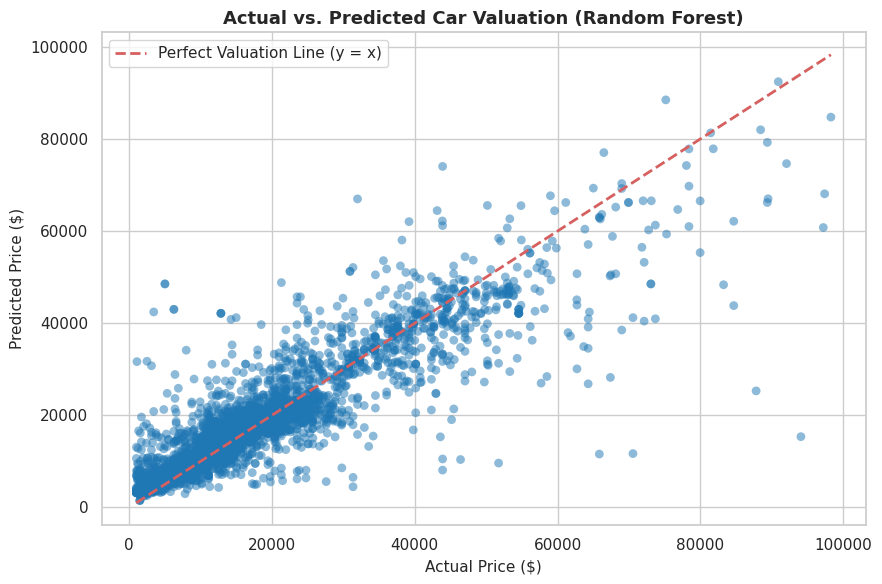

In [9]:
rf_best = models["Random Forest Regressor"]
y_pred_best = rf_best.predict(X_test)

plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred_best, color="#1f77b4", alpha=0.5, edgecolors="none", s=40)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--r", lw=2, label="Perfect Valuation Line (y = x)")

plt.title("Actual vs. Predicted Car Valuation (Random Forest)", fontsize=13, weight="bold")
plt.xlabel("Actual Price ($)", fontsize=11)
plt.ylabel("Predicted Price ($)", fontsize=11)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

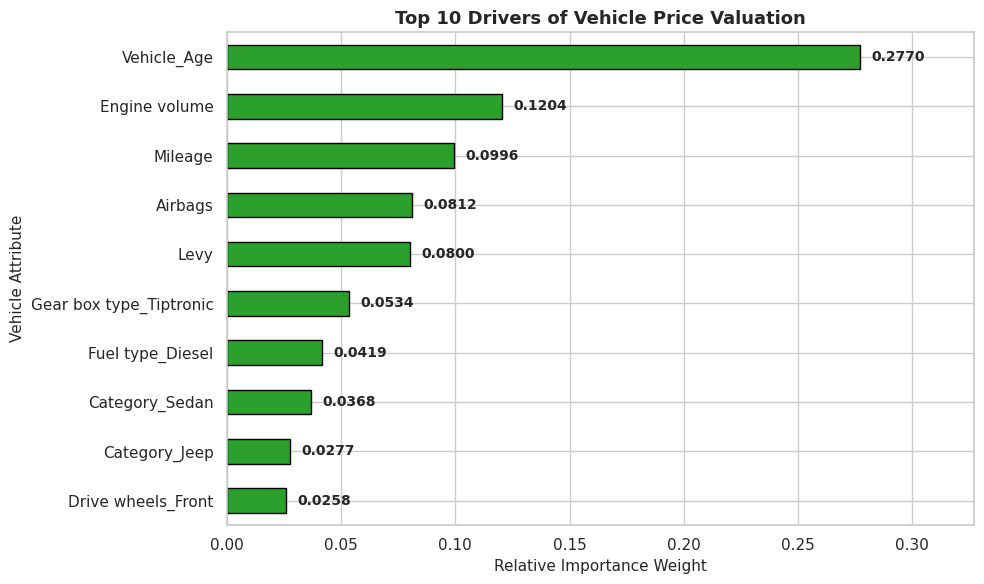

In [10]:
importances = pd.Series(rf_best.feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind="barh", color="#2ca02c", edgecolor="black")

plt.title("Top 10 Drivers of Vehicle Price Valuation", fontsize=13, weight="bold")
plt.xlabel("Relative Importance Weight", fontsize=11)
plt.ylabel("Vehicle Attribute", fontsize=11)

for i, v in enumerate(top_features):
    plt.text(v + 0.005, i, f"{v:.4f}", va="center", weight="bold", fontsize=10)

plt.xlim(0, max(top_features) + 0.05)
plt.tight_layout()
plt.show()